<a href="https://colab.research.google.com/github/aleexrtt/ProyectoFinal/blob/main/Proyecto_de_la_clase_de_modelaci%C3%B3n_del_aprendizaje_con_inteligencia_artificial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Price Prediction
## Proyecto final Modelación del aprendizaje con inteligencia artificial
### Diego Zermeño Viramontes | A01611907
### Jesús Higuera Alanís | A01708955
### Luis Alejandro Ruiz Trejo | A01613115
### Ximena González González | A01708366








##Introducción

Para la siguiente modelo se utilizaran las siguientes librerias:

El objetivo del siguiente proyecto por medio de técnicas de Machine Learning predecir el precio de cierre ajustado del día siguiente de un activo financiero, utilizando datos históricos obtenidos de Kaggle ([Dataset](https://www.kaggle.com/datasets/suruchiarora/yahoo-finance-dataset-2018-2023)), el dataset tiene a autor a Suruchi Arora, y tiene como propoósito  comprender, identificar patrones y estrategias financieras. El dataset muestra instrumentos financieros como diversos activos, como acciones, ETF e índices.

Gracias a esto el usuario *_hamid_sadeghi_1*, [Proyecto de Kaggle ](https://www.kaggle.com/code/hamidsadeghi1/yahoo-finance-stock-market-prediction) utilizo el dataset donde utiliza LSTM para predecir, debido al poco conocimiento que se tienen en las Long Short-Term Memory, se decidio realizarlo por medio de árboles de decisión, ensambles como Random Forest y un modelo base de referencia basado en referencia bayesiana.

Dentro de este proyecto el principal problema es que debido al contexto financiero predecir precios dentro de la bolsa de valores es bastante complejo debido a la alta volatilidad del mercado, influencia de factores externos y presencia de ruido en los datos.

Por otro lado, por medio de modelos de aprendizaje automático es posible identificar patrones históricos y relaciones entre variables como el precio de apertura, su precio máximo, precio mínimo, precio de cierre ajustado y el volumen de operaciones.


Para dar más contexto dentro de las técnicas a utilizar, los árboles de decisión según Ledesma (2026), un árbol de decisión es un modelo de aprendizaje supervisado que se utiliza para problemas de clasificación y regresión teniendo una estructura jerárquica que divide los datos en nodos basándose en las variables que maximizan la homogeneidad de los grupos resultantes.

Por otro lado existen los Random Forest, según Ledesma (2026), es un método de aprendizaje conjunto (ensemble learning) que construye múltiples árboles de decisión durante el entrenamiento. Cada árbol se entrena con una muestra aleatoria de los datos mediante una técnica llama Bootstrap y la predicción final se obtiene por votación en mayoría de clasificación o promedio en regresión, este tiene ventaja ante los árboles de decisión, esto son:

1.   Reducción de sobreajuste
2.   Mayor estabilidad
3.   Versatilidad de las variables

Finalmente, el modelo basado en la inferencia bayesiana según Noreña (s.f.), puede ser definida como un enfoque estadístico que permite estimar y actualizar la incertidumbre de los datos a medida que vamos obteniendo información, como fue visto en clase la probabilidad bayesiana permite actualizar y calcular lo que se conoce de algo observado, por lo tanto, trata los parámetros o variables desconocidas como variables aleatorias describiéndolas en términos de distribuciones de probabilidad.
Donde se basa en el Teorema de Bayes el cual establece una probabilidad posterior se relaciona con una probabilidad previa y la verosimilitud de lo observado, permitiendo actualizar continuamente la información.

#Librerias utilizadas

In [ ]:

import pandas as pd #Manipulación de datos y análisis de ellos.
import numpy as np #Calculo númerico
import matplotlib.pyplot as plt #Visualización de gráficos

from sklearn.tree import DecisionTreeRegressor, plot_tree #Árbol de decisión mediante Sklearn
from sklearn.ensemble import RandomForestRegressor #Random Forest por medio de Sklearn
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #Métricas necesarias para la implementación




El dataset fue obtenido en Yahoo Finance, contiene variables relacionadas con el comportamiento del mercado durante el 1ero Mayo del 2018 hasta el 28 de Abril del año 2023, las variables del conjunto de datos son:


| Variable | Descripción |
| :--- | :---:
| Date| Fecha de registro|
| Open| Precio de apertura del activo en ese día |
| High| Precio máximo alcanzado durante ese día|
| Low | Precio mínimo alcanzado durante el día|
| Close| Precio de cierre de la acción |
| Adj Close| Precio de cierre ajustado |
| Volume| Volumen de operaciones |

La variable *Adj Close* es la variable de nuestro interés debido a que es el precio de cierre ajustado esta considera dividendos, splits y otros ajustes financieros. Por esta razón, se suele utilizar como una medida estable y representativa del valor real a lo largo del tiempo


#Parte 1: Carga, Limpieza y Exploración de Datos

In [ ]:
df = pd.read_excel("yahoo_data.xlsx")

# Renombramos columnas para evitar caracteres especiales que son los "*" de la base de datos
df.columns = ["Date", "Open", "High", "Low", "Close", "Adj_Close", "Volume"]

# Convertimos la fecha y ordenamos cronológicamente (más antiguo primero)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

#Vemos la vista general del conjunto de datos
print("Vista general del dataset")
print(df.head())
print(f"\nForma del dataset: {df.shape}")
print(f"\nRango de fechas: {df['Date'].min().date()} → {df['Date'].max().date()}")
print("\nEstadísticas descriptivas:")
print(df.describe())


Vista general del dataset
        Date      Open      High       Low     Close  Adj_Close     Volume
0 2018-05-01  24117.29  24117.29  23808.19  24099.05   24099.05  380070000
1 2018-05-02  24097.63  24185.52  23886.30  23924.98   23924.98  385350000
2 2018-05-03  23836.23  23996.15  23531.31  23930.15   23930.15  389240000
3 2018-05-04  23865.22  24333.35  23778.87  24262.51   24262.51  329480000
4 2018-05-07  24317.66  24479.45  24263.42  24357.32   24357.32  307670000

Forma del dataset: (1258, 7)

Rango de fechas: 2018-05-01 → 2023-04-28

Estadísticas descriptivas:
                                Date          Open          High  \
count                           1258   1258.000000   1258.000000   
mean   2020-10-28 09:39:12.305246464  29595.823045  29776.945739   
min              2018-05-01 00:00:00  19028.360000  19121.010000   
25%              2019-07-31 06:00:00  26041.267500  26163.155000   
50%              2020-10-27 12:00:00  29201.410000  29335.685000   
75%             

In [ ]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())

print("\nTipos de datos:")
print(df.dtypes)


Valores nulos por columna:
Date         0
Open         0
High         0
Low          0
Close        0
Adj_Close    0
Volume       0
dtype: int64

Número de filas duplicadas:
0

Tipos de datos:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj_Close           float64
Volume                int64
dtype: object


Antes de realizar cualquier predicción, se observo la calidad de los datos, fue posible identificar que no hay valores nulos en cada columna, por lo que no fue necesario eliminar filas ni técnicas para imputar datos. Por otro lado, no existen datos duplicados por lo que el dataset funciona perfectamente para realizar las predicciones. Igualmente, las columnas tuvieron que ser renombradas para evitar errores en el codigo.
Con esto, la desviación estándar que muestra la variablilidad en los datos, en este caso se obtuvo dispersión natural en un mercado financiero.

Como nota, el *Adj_Close* y *Close* son iguales en todo el dataset por lo que se seleccionara para el entrenamiento la variable *Close*
**Amigos Podríamos agregar aquí un diagrama de dispersión o uno que muestre como se comportan los datos para que el proyecto se vea mejor**

Por otra parte no se escalaron los datos debido a que los datos no dependen de distancias ni gradientes. Estos modelos separan los datos mediante reglas basadas en umbrales, por lo que es posible usarse con las magnitudes originales

# Parte 2: Objetivo y Features

El objetivo del proyecto es predecir el precio de cierre ajustado al dia Siguiente por lo que se crea una variable llamada **Objetivo** desplazando la variable *Adj-Close* un día hacia atrás. Por otro lado, para realizar las predicciones es necesario variables de entrada y una salida. En este caso, las variables de entrada corresponden a los datos financieros del dia actual *"Open", "High", "Low", "Adj_Close", "Volume"* y deben estimar el precio de cierre ajustado al dia siguiente. Mientras que, nuestra variable objetivo o de salida es *AdjClose* la que predice el precio de cierre ajustado al dia siguiente

In [ ]:
# Nuestro objetivo es predecir el precio de cierre ajustado del día SIGUIENTE
# Creamos la columna desplazando Adj_Close un día hacia atrás
df["Target"] = df["Adj_Close"].shift(-1)

# Eliminamos la última fila (no tiene día siguiente)
df = df.dropna().reset_index(drop=True)

#El archivo original contiene 1258 registros.
#Después de crear la variable objetivo con shift(-1),
#se eliminó la última fila porque no existe un valor real del día siguiente para compararla.
#Por eso, el entrenamiento y la prueba tenemos 1257 datos

# Features: columnas OHLCV del día actual
features = ["Open", "High", "Low","Close", "Volume"]

X = df[features]
y = df["Target"]

print("\n Variables del modelo")
print(f"Features (X): {features}")
print(f"Target  (y): Adj_Close del día siguiente")
print(f"Total de muestras: {len(X)}")



 Variables del modelo
Features (X): ['Open', 'High', 'Low', 'Close', 'Volume']
Target  (y): Adj_Close del día siguiente
Total de muestras: 1257


# Parte 3: División de Entrenamiento y Prueba

Dentro del uso de IA ChatGPT recomendo usar una división cronológica 80% y 20%, sin mezclar los datos.
La división cronológica se realizo debido a que el dataset contiene una serie temporal financiera. Por lo que el equipo decidio entrenar con datos históricos de 2018 a 2022 y probando como datos posteriores de 2022 a 2023.

In [ ]:
# Para series de tiempo NO usamos shuffle; respetamos el orden cronológico
split_index = int(len(X) * 0.80)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print("\n División de datos")
print(f"Entrenamiento: {len(X_train)} muestras "
      f"({df['Date'].iloc[0].date()} → {df['Date'].iloc[split_index-1].date()})")
print(f"Prueba:        {len(X_test)} muestras "
      f"({df['Date'].iloc[split_index].date()} → {df['Date'].iloc[-1].date()})")


 División de datos
Entrenamiento: 1005 muestras (2018-05-01 → 2022-04-26)
Prueba:        252 muestras (2022-04-27 → 2023-04-27)


# Parte 4: Árbol de Decisión para regresión

El primer modelo que se uso para predecir fue un Árbol de Decisión de regresión
explicado en la introducción del notebook, el algoritmo de la libreria de sklearn, divide los datos en nodos mediante reglas de decisión. En cada división, el modelo selecciona una característica y un punto de corte que reduzca el error de predicción.

En este caso debido a que es un árbol de regresión, el árbol intenta minimizar la varianza o el error cuadrático en cada nodo. Al final cada hoja del árbol contiene una predicción numérica, usualmente el promedio de los valores de entrenamiento que llegaron a esa hoja.

Es decir, si el precio de apertura es mayor a x valor y el volumen está dentro de cierto rango, entonces se predice un precio de cierre ajustado.

Gracias a esta libreria y a que es un modelo parámetrico es posible decidir que tanto queremos que el modelo entrene, para que un modelo tenga un entrenamiento profundo, internamente el entrenamiento realiza lo siguiente:
1. Construcción Recursiva: Esto es un proceso de división binaria descente por medio de el algoritmo greedy para mejorar la separación en cada división.
2. Segmentación Progresiva: Todos los datos se dividen en subconjuntos creando grupos con características similares.
3. Control de Complejidad: Genera implementación de técnicas de poda y validación cruzada para prevenir el sobreajuste y tener una mejora en la generalización.

Pero si el árbol esta demasiado profundo puede memorizar el conjunto de entrenamiento perdiendo capacidad de generalizar ante nuevos datos (Ledesma, 2026).



In [ ]:

dt_model = DecisionTreeRegressor(
    max_depth=5,           # limitamos profundidad para evitar overfitting
    criterion="squared_error",
    random_state=42,

)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("\n Resultados: Decision Tree")
dt_mae  = mean_absolute_error(y_test, dt_pred)
dt_mse  = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2   = r2_score(y_test, dt_pred)

print(f"MAE:  {dt_mae:,.2f}")
print(f"MSE:  {dt_mse:,.2f}")
print(f"RMSE: {dt_rmse:,.2f}")
print(f"R²:   {dt_r2:.4f}")


 Resultados: Decision Tree
MAE:  369.49
MSE:  232,368.86
RMSE: 482.05
R²:   0.8699


## Interpretación de Resultados
Para evitar el overfitting se quizo demostrar las métricas tanto en el entrenamiento como en la prueba obteniendo lo siguiente:

In [ ]:
# Predicciones en entrenamiento y prueba
y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

# Métricas entrenamiento
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

# Métricas prueba
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("Resultados: Decision Tree - Entrenamiento")
print(f"MAE: {mae_train:.2f}")
print(f"MSE: {mse_train:,.2f}")
print(f"RMSE: {rmse_train:.2f}")
print(f"R²: {r2_train:.4f}")

print("\nResultados: Decision Tree - Prueba")
print(f"MAE: {mae_test:.2f}")
print(f"MSE: {mse_test:,.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R²: {r2_test:.4f}")

Resultados: Decision Tree - Entrenamiento
MAE: 229.16
MSE: 105,218.57
RMSE: 324.37
R²: 0.9938

Resultados: Decision Tree - Prueba
MAE: 369.49
MSE: 232,368.86
RMSE: 482.05
R²: 0.8699


Al comparar el desempeño del modelo en entrenamiento y prueba, el \R^2 de entrenamiento fue de 0.9938, mientras que el \R^2  de prueba fue de 0.8699.
La diferencia indica que el modelo se ajusta mejor a los datos de entrenamiento que a los no vistos en este caso son los datos de los años 2022 a 2023. El MAE aumenta de 229.50 en entrenamiento a 369.39, esto es aceptable pero pierde precisión al generalizar. Podemos concluir que el Árbol de Decisión de Regresión presenta un ligero sobreajuste pero sigue siendo aceptable en la prueba.


# Parte 5: Random Forest Regressor

Para el segundo modelo que se uso fue Random Forest Regressor, a diferencia del modelo anterior este tiene 3 características:

1. Reducción de Sobreajuste: Los diferentes árboles compensan errores individuales, mejorando la robustez del modelo

2. Mayor Estabilidad: Existen pequeñas variaciones en los datos esto nos da un menor impacto en las predicciones finales.

3. Versatilidad de Variables: Simultáneamente maneja variables continuas sin necesidad de transformaciones complejas.

In [ ]:

# Predicciones en entrenamiento y prueba
rf_model = RandomForestRegressor(
    n_estimators=100,      # 100 árboles en el bosque
    max_depth=5,           # misma profundidad máxima que el DT para comparar justo
    criterion="squared_error",
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

y_train_pred_rf = rf_model.predict(X_train)
y_test_pred_rf = rf_model.predict(X_test)

# Métricas de entrenamiento
mae_train_rf = mean_absolute_error(y_train, y_train_pred_rf)
mse_train_rf = mean_squared_error(y_train, y_train_pred_rf)
rmse_train_rf = np.sqrt(mse_train_rf)
r2_train_rf = r2_score(y_train, y_train_pred_rf)

# Métricas de prueba
mae_test_rf = mean_absolute_error(y_test, y_test_pred_rf)
mse_test_rf = mean_squared_error(y_test, y_test_pred_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
r2_test_rf = r2_score(y_test, y_test_pred_rf)

print("Resultados: Random Forest - Entrenamiento")

print(f"MAE: {mae_train_rf:.2f}")
print(f"MSE: {mse_train_rf:,.2f}")
print(f"RMSE: {rmse_train_rf:.2f}")
print(f"R²: {r2_train_rf:.4f}")

print("\nResultados: Random Forest - Prueba")
print(f"MAE: {mae_test_rf:.2f}")
print(f"MSE: {mse_test_rf:,.2f}")
print(f"RMSE: {rmse_test_rf:.2f}")
print(f"R²: {r2_test_rf:.4f}")


Resultados: Random Forest - Entrenamiento
MAE: 198.44
MSE: 83,613.28
RMSE: 289.16
R²: 0.9951

Resultados: Random Forest - Prueba
MAE: 323.77
MSE: 177,595.90
RMSE: 421.42
R²: 0.9006


## Interpretación de Resultados
Igual que en el Árbol de Decisión, el Random Forest obtuvo un MAE de 322.78 un RMSE de 421.42 y un \R^2 de 0.9006 en la prueba. Los resultados indican que el modelo explica aproximadamente el 90.06% de la variabilidad de los datos y presentaun error promedio de 323.77. Al comparar con el conjunto de entrenamiento, donde obtuvo un \R^2 de 0.9951, igualmente que en el árbol de decisión podemos identificar un sobreajuste observado pero el Random Forest presento mejoría y se considera más robusto en este tipo de problemas.


# Parte 6: Modelo de Inferencia Bayesiana

Para esta parte se implementó una línea base ingenua. Esta predicción asume que el valor de Adj_Close del día siguiente será igual al valor de Adj_Close del día actual.

Esto es importante en series financieras porque los precios suelen tener alta continuidad entre días continuos. Si un modelo complejo no supera esta referencia simple, entonces no se puede afirmar que el modelo aprendió patrones útiles

In [ ]:
# Predicción ingenua: el valor de mañana será igual al Adj_Close de hoy
baseline_pred_train = df["Adj_Close"].iloc[:split_index].values
baseline_pred_test = df["Adj_Close"].iloc[split_index:].values


# Métricas entrenamiento
baseline_mae_train = mean_absolute_error(y_train, baseline_pred_train)
baseline_mse_train = mean_squared_error(y_train, baseline_pred_train)
baseline_rmse_train = np.sqrt(baseline_mse_train)
baseline_r2_train = r2_score(y_train, baseline_pred_train)


# Métricas prueba
baseline_mae_test = mean_absolute_error(y_test, baseline_pred_test)
baseline_mse_test = mean_squared_error(y_test, baseline_pred_test)
baseline_rmse_test = np.sqrt(baseline_mse_test)
baseline_r2_test = r2_score(y_test, baseline_pred_test)


print("Resultados: Baseline Ingenuo - Entrenamiento")

print(f"MAE: {baseline_mae_train:.2f}")
print(f"MSE: {baseline_mse_train:,.2f}")
print(f"RMSE: {baseline_rmse_train:.2f}")
print(f"R²: {baseline_r2_train:.4f}")

print("Resultados: Baseline Ingenuo - Prueba")
print(f"MAE: {baseline_mae_test:.2f}")
print(f"MSE: {baseline_mse_test:,.2f}")
print(f"RMSE: {baseline_rmse_test:.2f}")
print(f"R²: {baseline_r2_test:.4f}")

Resultados: Baseline Ingenuo - Entrenamiento
MAE: 230.41
MSE: 125,249.32
RMSE: 353.91
R²: 0.9926
Resultados: Baseline Ingenuo - Prueba
MAE: 288.96
MSE: 145,819.10
RMSE: 381.86
R²: 0.9187


## Interpretación de Resultados

Para comparar el Random Forest y el Árbol de Decisión de Regresión se decidio implementar un modelo baseline, en este caso sería el valor del día siguiente es decir el Adj_Close, obteniendo que el valor de MAE fue de 288.96, un RMSE de 381.86 y un \R^2 de 0.9187. Estos resultados pasan a los obtenidos por Decision Tree y Random Forest, lo cual indica que, para esta serie temporal, el comportamiento que es más reciente del precio es un predictor muy fuerte. Por lo que, los modelos de Machine Learning evaluados no lograron superar a la línea base.

#Parte 7: Comparación de Resultados

In [ ]:
resultados_modelos = pd.DataFrame({
    "Modelo": ["Baseline ingenuo", "Decision Tree", "Random Forest"],
    "MAE": [baseline_mae_test, dt_mae, mae_test_rf],
    "MSE": [baseline_mse_test, dt_mse, mse_test_rf],
    "RMSE": [baseline_rmse_test, dt_rmse, rmse_test_rf],
    "R^2": [baseline_r2_test, dt_r2, r2_test_rf]
})

print("Comparación de modelos")

print(resultados_modelos.to_string(index=False))

Comparación de modelos
          Modelo        MAE           MSE       RMSE      R^2
Baseline ingenuo 288.959643 145819.102800 381.862675 0.918703
   Decision Tree 369.490820 232368.864187 482.046537 0.869896
   Random Forest 323.773552 177595.901223 421.421287 0.900564


## Interpretación de resultados
### Comparación general de modelos

Al comparar los tres modelos, se identifica que el Baseline ingenuo obtuvo el mejor desempeño ya que presento el menor MAE con 288.96, RMSE de 381.86 y finalmente un mejor \R^2 de 0.9187, teniendo una mejor capacidad de generalizar.

A comparación con los demás modelos Random Forest tuvo un mejor desempeño que Decision Tree. El Random Forest bajo el MAE de 359.39 a 322.78, igualmente el  RMSE de 463.30 a 420.14 y subio el \R^2 de 0.8803 a 0.9016. Por lo que usar varios árboles de decisión nos permitio obtener mejores predicciones que un solo árbol de decisión.

Entre estos 3, Random Forest mejoró a comparación del Decision Tree, pero no supero al Baseline ingenuo.

Para concluir este análisis el mejor modelo según las métricas obtenidas fue el Baseline ingenuo. Concluimos que, para esta serie temporal, el valor actual de *Adj_Close* es una referencia muy fuerte para predecir el siguiente valor, y que los modelos complejos no aportaron una mejora frente a una esta regla.

# Parte 8: Gráficos
*Esta parte no se interpretará dentro del notebook debido a que es apoyo visual para la presentación*

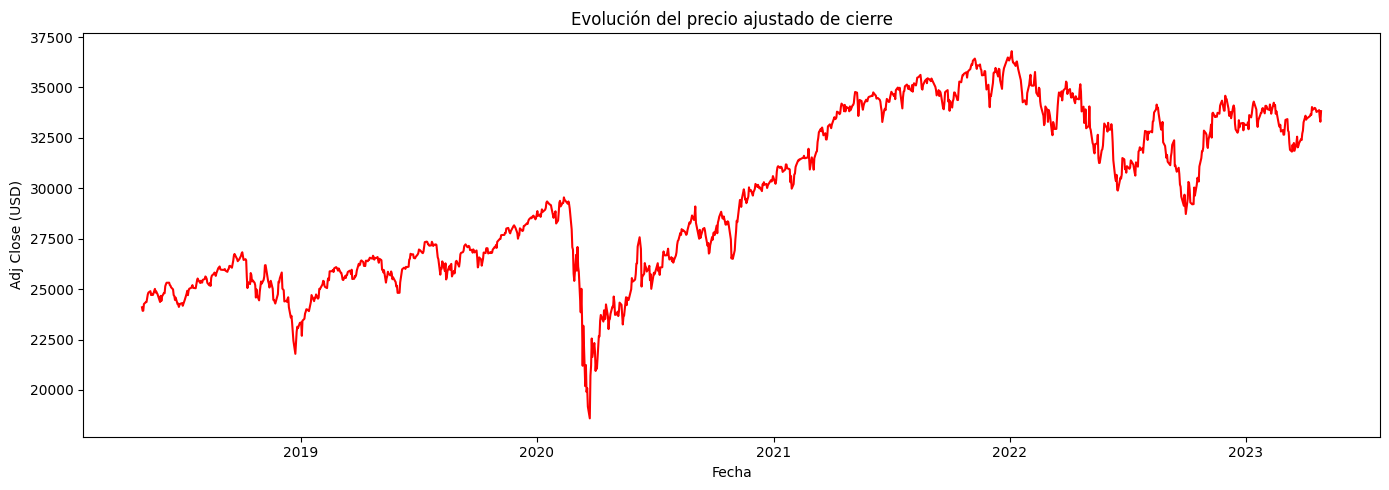

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Adj_Close"], color="red", linewidth=1.5)
plt.title("Evolución del precio ajustado de cierre")
plt.xlabel("Fecha")
plt.ylabel("Adj Close (USD)")
plt.tight_layout()
plt.show()

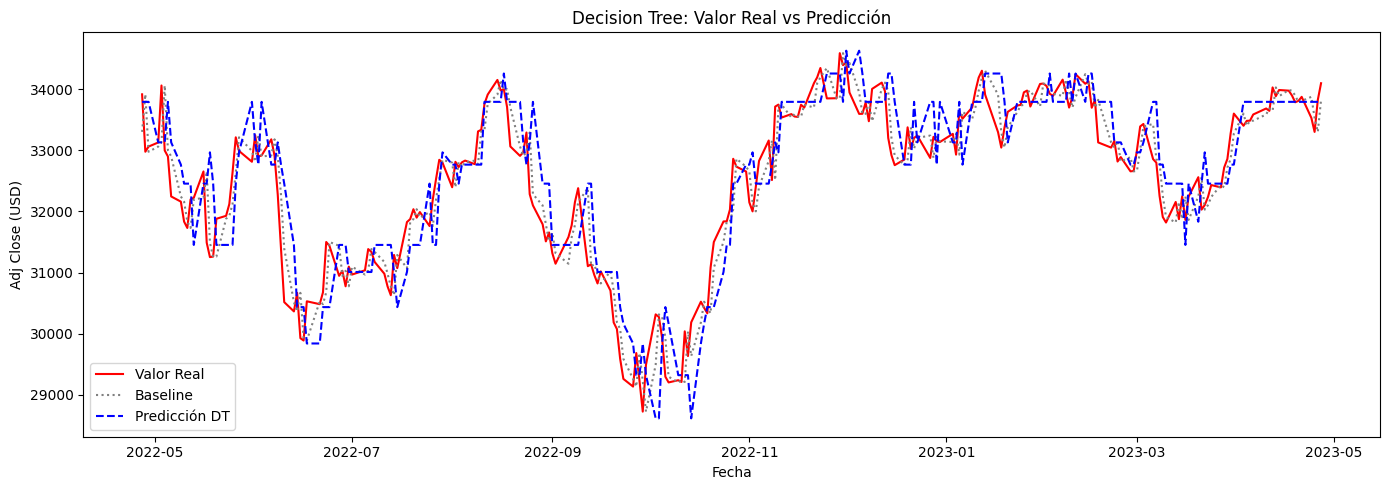

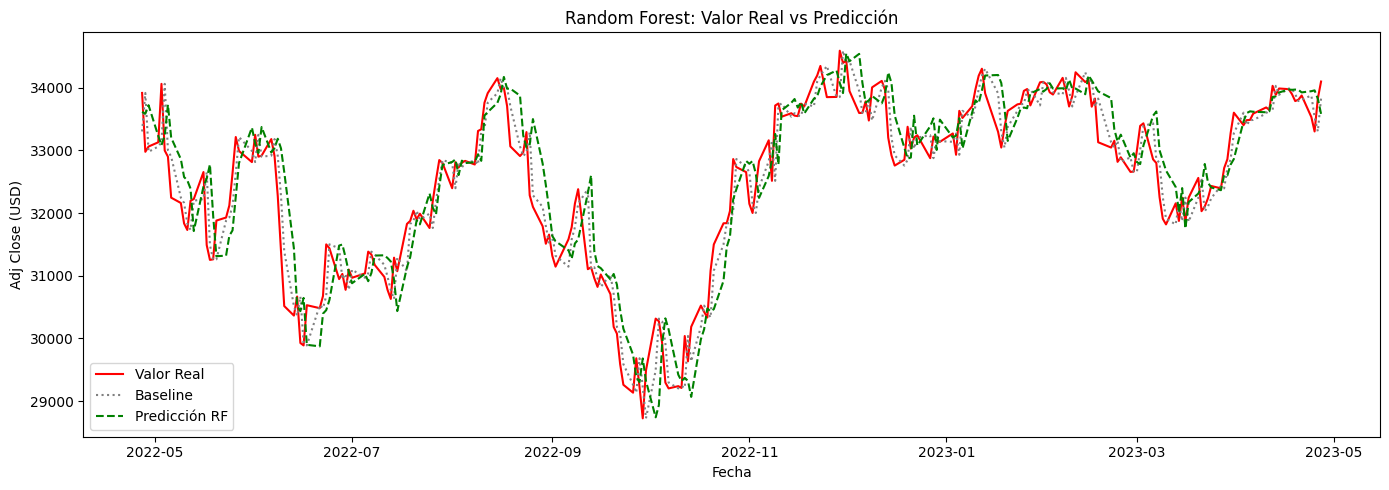

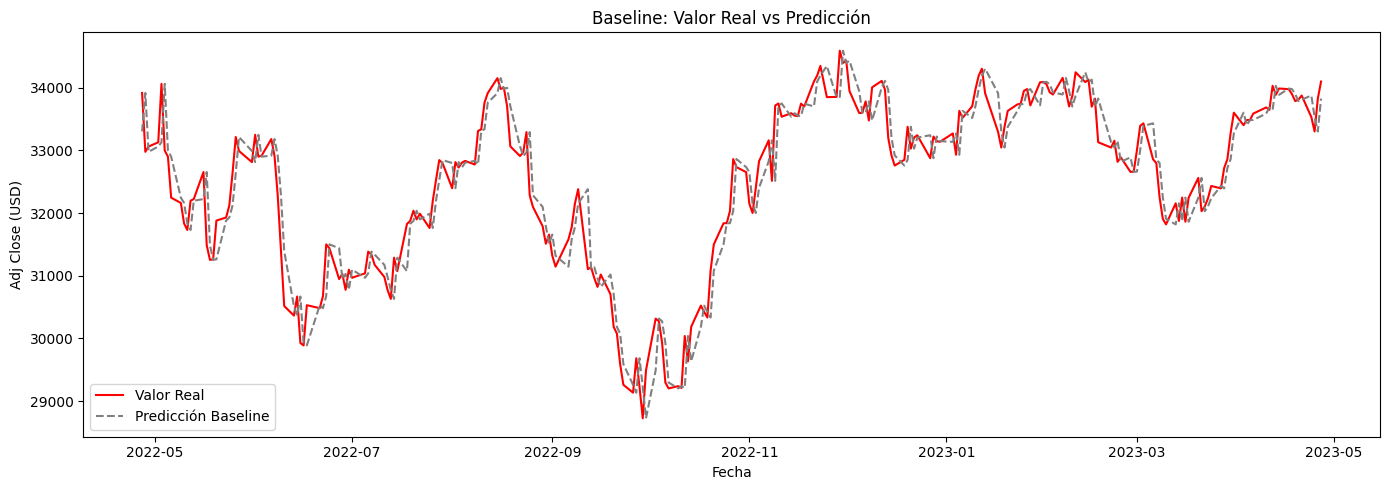

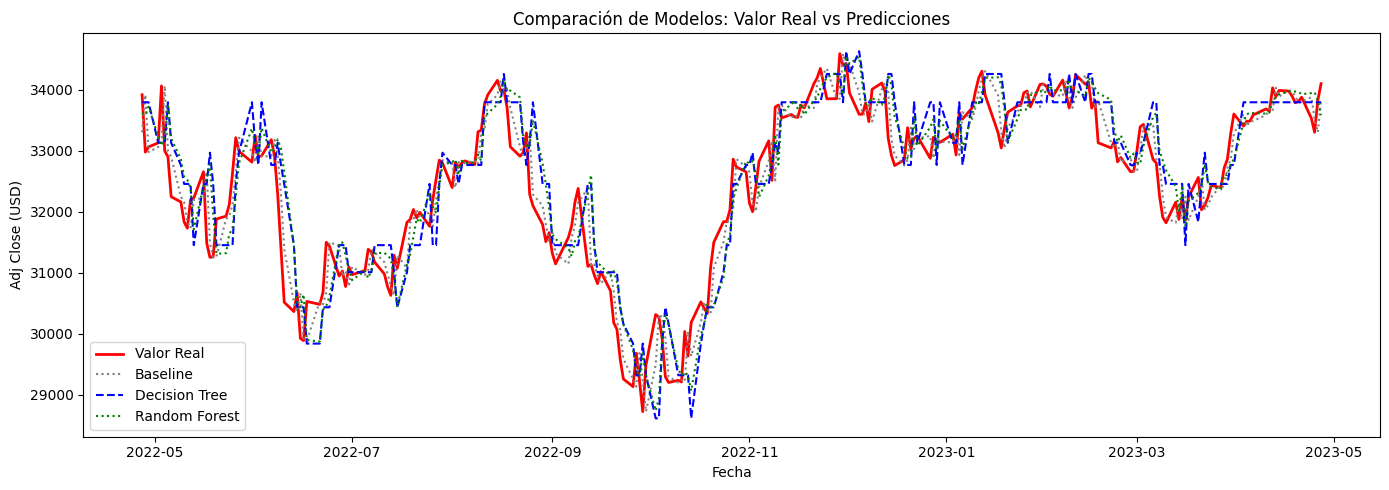

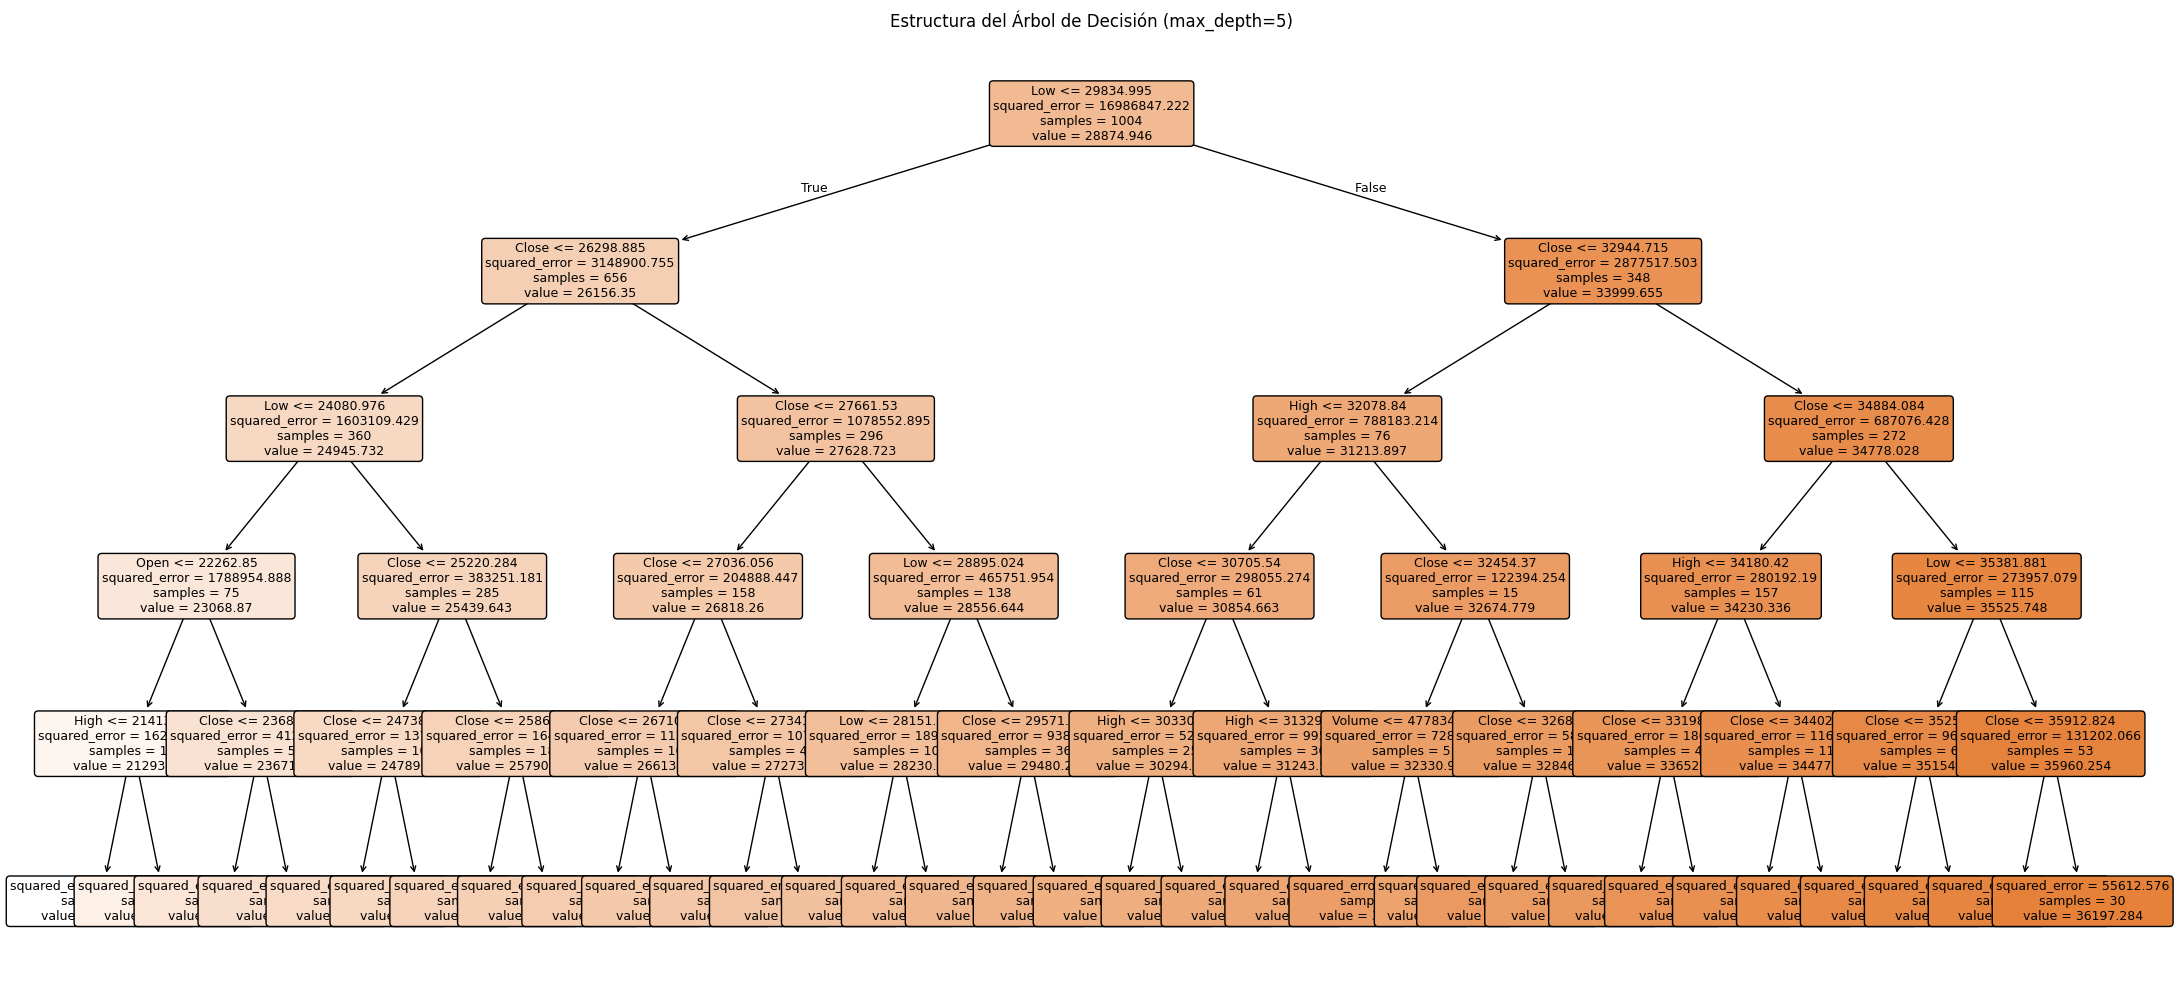

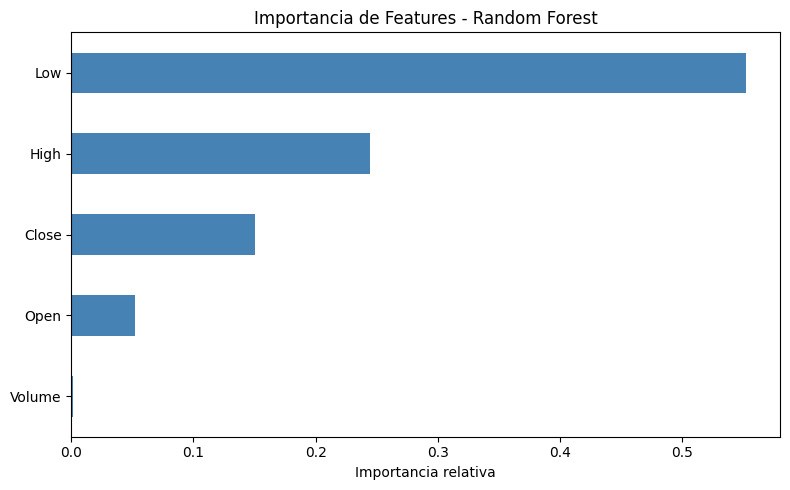

In [ ]:
fechas_test = df["Date"].iloc[split_index:].values

# La gráfica 1 compara las predicciones vs el valor real (Decision Tree)
plt.figure(figsize=(14, 5))
plt.plot(fechas_test, y_test.values, label="Valor Real", color="red", linewidth=1.5)
plt.plot(fechas_test, baseline_pred_test, label="Baseline", color="gray", linewidth=1.5, linestyle=":")
plt.plot(fechas_test, dt_pred, label="Predicción DT", color="blue", linewidth=1.5, linestyle="--")
plt.title("Decision Tree: Valor Real vs Predicción")
plt.xlabel("Fecha")
plt.ylabel("Adj Close (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# La gráfica 2 compara las predicciones vs el valor real (Random Forest)
plt.figure(figsize=(14, 5))
plt.plot(fechas_test, y_test.values, label="Valor Real", color="red", linewidth=1.5)
plt.plot(fechas_test, baseline_pred_test, label="Baseline", color="gray", linewidth=1.5, linestyle=":")
plt.plot(fechas_test, rf_pred, label="Predicción RF", color="green", linewidth=1.5, linestyle="--")
plt.title("Random Forest: Valor Real vs Predicción")
plt.xlabel("Fecha")
plt.ylabel("Adj Close (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# La gráfica 3 compara el valor real vs el baseline
plt.figure(figsize=(14, 5))
plt.plot(fechas_test, y_test.values, label="Valor Real", color="red", linewidth=1.5)
plt.plot(fechas_test, baseline_pred_test, label="Predicción Baseline", color="gray", linewidth=1.5, linestyle="--")
plt.title("Baseline: Valor Real vs Predicción")
plt.xlabel("Fecha")
plt.ylabel("Adj Close (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# La gráfica 4 compara ambos modelos junto con el baseline
plt.figure(figsize=(14, 5))
plt.plot(fechas_test, y_test.values, label="Valor Real", color="red", linewidth=2)
plt.plot(fechas_test, baseline_pred_test, label="Baseline", color="gray", linewidth=1.5, linestyle=":")
plt.plot(fechas_test, dt_pred, label="Decision Tree", color="blue", linewidth=1.5, linestyle="--")
plt.plot(fechas_test, rf_pred, label="Random Forest", color="green", linewidth=1.5, linestyle=":")
plt.title("Comparación de Modelos: Valor Real vs Predicciones")
plt.xlabel("Fecha")
plt.ylabel("Adj Close (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# La gráfica 5, muestra una visualización del árbol de decisión
plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=features,
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Estructura del Árbol de Decisión (max_depth=5)")
plt.tight_layout()
plt.show()

# La gráfica 6, muestra la importancia de features (Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.title("Importancia de Features - Random Forest")
plt.xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

#Limitaciones del proyecto
Una limitación vista por el equipo es que se realizó con una única división cronológica 80/20. Para un análisis más robusto, se podría utilizar TimeSeriesSplit, que permite evaluar el modelo en múltiples ventanas temporales respetando el orden cronológico de los datos.

# **Referencias**

ALEJANDRA, L. (2023, July 4). Inferencia bayesiana en el aprendizaje automático | Procesado Avanzado de Señales y Datos. Blogs.Upm.Es. https://blogs.upm.es/pasd/2023/07/04/inferencia-bayesiana-en-el-aprendizaje-automatico/
‌
Belcic, I., & Stryker, C. (2025, September 12). aprendizaje supervisado. Ibm.Com. https://www.ibm.com/mx-es/think/topics/supervised-learning
‌
Ledezma, L.Árboles de Decisión y Random Forest: Fundamentos y Aplicaciones en Finanzas. (2026). https://gamma.app/docs/Arboles-de-Decision-y-Random-Forest-Fundamentos-y-Aplicaciones-en-8lqxyaoerar0vjh?mode=doc
‌

Presentaciones e información obtenida de la clase

University Carlemany.(2026).La inferencia bayesiana y su uso en data science https://www.universitatcarlemany.com/actualidad/blog/inferencia-bayesiana